# [ Computer Vision ] [ CSE445 ] [ Assignment-1 ]

**Dataset Name:** IoTKITs<br>
**Source Link:** https://data.mendeley.com/datasets/x5thzmkxhy/1

## Configuration

In [1]:
import json
import os
import pandas as pd

data = "/kaggle/input/datasets/Mrpaul0007/iotkits"
train_dir = "/kaggle/input/datasets/Mrpaul0007/iotkits/train"
valid_dir = "/kaggle/input/datasets/Mrpaul0007/iotkits/valid"
test_dir = "/kaggle/input/datasets/Mrpaul0007/iotkits/test"

train_annotation = "/kaggle/input/datasets/Mrpaul0007/iotkits/train/_annotations.coco.json"
valid_annotation = "/kaggle/input/datasets/Mrpaul0007/iotkits/valid/_annotations.coco.json"
test_annotation = "/kaggle/input/datasets/Mrpaul0007/iotkits/test/_annotations.coco.json"

working_dir = "/kaggle/working/"
checkpoint_dir = os.path.join(working_dir, "checkpoints")
result_dir = os.path.join(working_dir, "results")
for d in [checkpoint_dir, result_dir]:
    os.makedirs(d, exist_ok=True)

MODEL_VARIANT = "nano"

EPOCHS = 20
INPUT_RESOLUTION = 640
BACKBONE_LR = 1e-5
HEAD_LR = 1e-4
GRAD_CLIP_MAX_NORM = 0.1
WARMUP_EPOCHS = 3
FROZEN_BACKBONE_EPOCHS = 7

BATCH_SIZE = 4
GRAD_ACCUM = 4
NUM_DEVICES = 1

CONF_THRESHOLD = 0.25

print("===== RF-DETR CONFIG =====")
print(f"Variant: {MODEL_VARIANT}")
print(f"Epochs: {EPOCHS}")
print(f"Resolution: {INPUT_RESOLUTION}")
print(f"Backbone LR: {BACKBONE_LR} | Head LR: {HEAD_LR}")
print(f"Gradient clip norm: {GRAD_CLIP_MAX_NORM}")
print(f"Warmup epochs: {WARMUP_EPOCHS} | Frozen-backbone epochs: {FROZEN_BACKBONE_EPOCHS}")
print(f"Batch size: {BATCH_SIZE} | Grad accum: {GRAD_ACCUM} | Effective batch: {BATCH_SIZE*GRAD_ACCUM}")
print(f"Devices: {NUM_DEVICES}")

print("\n===== DATA PATHS =====")
for name, path in [("train_dir", train_dir), ("valid_dir", valid_dir), ("test_dir", test_dir),("train_annotation", train_annotation), ("valid_annotation", valid_annotation),("test_annotation", test_annotation)]:
    print(f"{name}: {path}")


def class_name(path):
    class_list = []
    with open(path, "r") as f:
        data = json.load(f)

        if "categories" in data:
            for category in data["categories"]:
                class_list.append({"Id": category["id"], "Name": category["name"]})
            df = pd.DataFrame(class_list).sort_values("Id").reset_index(drop=True)
            return df
        else:
            return "No Categories Found!"

print("\nClass Names with ID:")
display(class_name(train_annotation).style.hide(axis="index"))
print("Valid_Annotation_Class_name:")
display(class_name(valid_annotation).style.hide(axis="index"))
print("\nConfiguration Loaded Successfully!")

===== RF-DETR CONFIG =====
Variant: nano
Epochs: 20
Resolution: 640
Backbone LR: 1e-05 | Head LR: 0.0001
Gradient clip norm: 0.1
Warmup epochs: 3 | Frozen-backbone epochs: 7
Batch size: 4 | Grad accum: 4 | Effective batch: 16
Devices: 1

===== DATA PATHS =====
train_dir: /kaggle/input/datasets/Mrpaul0007/iotkits/train
valid_dir: /kaggle/input/datasets/Mrpaul0007/iotkits/valid
test_dir: /kaggle/input/datasets/Mrpaul0007/iotkits/test
train_annotation: /kaggle/input/datasets/Mrpaul0007/iotkits/train/_annotations.coco.json
valid_annotation: /kaggle/input/datasets/Mrpaul0007/iotkits/valid/_annotations.coco.json
test_annotation: /kaggle/input/datasets/Mrpaul0007/iotkits/test/_annotations.coco.json

Class Names with ID:


Id,Name
1,Arduino Mega 2560 -Black-
2,Arduino Mega 2560 -Blue-
3,Arduino Mega 2560 -Yellow-
4,Arduino Uno -Black-
5,Arduino Uno -Green-
6,Arduino Uno Camera Shield
7,Arduino Uno WiFi Shield
8,Arduino-Due
9,Arduino-Micro
10,Arduino-Nano


Valid_Annotation_Class_name:


Id,Name
1,Arduino Mega 2560 -Black-
2,Arduino Mega 2560 -Blue-
3,Arduino Mega 2560 -Yellow-
4,Arduino Uno -Black-
5,Arduino Uno -Green-
6,Arduino Uno Camera Shield
7,Arduino Uno WiFi Shield
8,Arduino-Due
9,Arduino-Micro
10,Arduino-Nano



Configuration Loaded Successfully!


### Model Size Justification — RF-DETR

**Dataset Size:** The IoTKITs dataset contains **3,107 images** total. Standard practice for model-size selection (as with **YOLO**) generalizes to **RF-DETR's** variants (**Nano/Small/Medium/Large**) as well: smaller datasets (**<3,000** images) favor **smaller model variants** to avoid **overfitting**, while larger datasets (**3,000+**) can support **medium/large** variants without overfitting risk. Our dataset sits right at this boundary (only **3.5%** above the **3,000-image threshold**), meaning a slightly larger variant could also have been reasonable — so we didn't pick `Nano` on image count alone; we also checked how the model actually performed during training to confirm it was the right choice (validated below, after full training).

## Environment Setup

In [2]:
!pip install rfdetr[train,loggers] --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 604.4/604.4 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.6/376.6 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 534.

In [3]:
!pip install ultralytics --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 4.5 MB/s eta 0:00:00


In [4]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Available GPU:",torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(i, torch.cuda.get_device_name(i))
else:
    print("WARNING: No GPU detected — check Settings > Accelerator > GPU T4")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Available GPU: 2
0 Tesla T4
1 Tesla T4


## Data Load Verify

In [5]:
import json

for name, path in [("train_split", train_annotation), ("valid_split", valid_annotation), ("test_split", test_annotation)]:
    with open (path, "r") as f:
        d = json.load(f)
        print(f"{name}: {len(d['images'])} images, {len(d['annotations'])} annotations, {len(d['categories'])} categories")

train_split: 2485 images, 2619 annotations, 32 categories
valid_split: 311 images, 322 annotations, 32 categories
test_split: 311 images, 325 annotations, 32 categories


## 1-EPOCH Dry Run

In [6]:
from rfdetr import RFDETRNano
import time

model = RFDETRNano()

print("\n1-EPOCH Dry Run")
print("-" * 20)

start_time = time.time()

model.train(
    dataset_dir = data,
    epochs = 1,
    batch_size = BATCH_SIZE,
    grad_accum_steps = GRAD_ACCUM,
    lr = HEAD_LR,
    lr_encoder = BACKBONE_LR,
    resolution = INPUT_RESOLUTION,
    output_dir = checkpoint_dir,
    devices = NUM_DEVICES,
    clip_max_norm = GRAD_CLIP_MAX_NORM, 
    warmup_epochs = WARMUP_EPOCHS,
)

elapsed = time.time() - start_time

print(f"\n1-epoch dry run completed in {elapsed/60:.2f} minutes")
print(f"Estimated time for {EPOCHS} epochs: {(elapsed/60)*EPOCHS:.2f} minutes")

[2026-08-29 16:34:50] [INFO] rf-detr - Downloading pretrained weights for /root/.roboflow/models/rf-detr-nano.pth


/root/.roboflow/models/rf-detr-nano.pth:   0%|          | 0.00/349M [00:00<?, ?iB/s]

[2026-08-29 16:34:55] [INFO] rf-detr - MD5 validation successful for /root/.roboflow/models/rf-detr-nano.pth


[2026-08-29 16:34:55] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-29 16:34:55] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-08-29 16:34:56] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.

1-EPOCH Dry Run
--------------------


...

Trainable params: 30.7 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 30.7 M                                                                                               
Total estimated model params size (MB): 122.607                                                                    
Modules in train mode: 449                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[2026-08-29 16:46:57] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/checkpoints/checkpoint_best_regular.pth (epoch 0, monitor=val/mAP_50_95, value=0.0672323)
[2026-08-29 16:46:58] [INFO] rf-detr - Best EMA mAP improved to 0.0689 (epoch 0)


`Trainer.fit` stopped: `max_epochs=1` reached.


[2026-08-29 16:47:00] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.0672, ema=0.0689)

1-epoch dry run completed in 12.05 minutes
Estimated time for 20 epochs: 241.04 minutes


## Full Training (20-epochs)

In [7]:
from rfdetr import RFDETRNano
import glob
import time

frozen_epochs = min(FROZEN_BACKBONE_EPOCHS, EPOCHS - 1)
remaining_epochs = EPOCHS - frozen_epochs
stage1_dir = os.path.join(checkpoint_dir, "stage1_frozen_backbone")
os.makedirs(stage1_dir, exist_ok=True)

print(f"\nFull Training with {EPOCHS} epochs "
      f"(backbone frozen for the first {frozen_epochs}, unfrozen for the remaining {remaining_epochs})")
print("-" * 20)

start_time = time.time()

print(f"\nStage 1/2: {frozen_epochs} epoch(s) with the backbone frozen (freeze_encoder=True)")
model = RFDETRNano(freeze_encoder=True)
model.train(
    dataset_dir = data,
    epochs = frozen_epochs,
    batch_size = BATCH_SIZE,
    grad_accum_steps = GRAD_ACCUM,
    lr = HEAD_LR,
    lr_encoder = BACKBONE_LR,
    resolution = INPUT_RESOLUTION,
    output_dir = stage1_dir,
    devices = NUM_DEVICES,
    clip_max_norm = GRAD_CLIP_MAX_NORM,
    warmup_epochs = WARMUP_EPOCHS,
)

stage1_candidates = [
    os.path.join(stage1_dir, "checkpoint_best_total.pth"),
    os.path.join(stage1_dir, "checkpoint_best_regular.pth"),
    os.path.join(stage1_dir, "checkpoint_best_ema.pth"),
]
stage1_ckpt = next((p for p in stage1_candidates if os.path.exists(p)), None)
if stage1_ckpt is None:
    other_ckpts = sorted(glob.glob(os.path.join(stage1_dir, "**", "*.pth"), recursive=True))
    stage1_ckpt = other_ckpts[-1] if other_ckpts else None
if stage1_ckpt is None:
    raise FileNotFoundError(f"No stage-1 checkpoint found under {stage1_dir}; cannot start stage 2.")

print(f"\nStage 2/2: {remaining_epochs} epoch(s) with the backbone unfrozen, "
      f"resuming from {stage1_ckpt}")
model = RFDETRNano(pretrain_weights=stage1_ckpt)
model.train(
    dataset_dir = data,
    epochs = remaining_epochs,
    batch_size = BATCH_SIZE,
    grad_accum_steps = GRAD_ACCUM,
    lr = HEAD_LR,
    lr_encoder = BACKBONE_LR,
    resolution = INPUT_RESOLUTION,
    output_dir = checkpoint_dir,
    devices = NUM_DEVICES,
    clip_max_norm = GRAD_CLIP_MAX_NORM,
    warmup_epochs = WARMUP_EPOCHS,
)

elapsed = time.time() - start_time

print(f"\nFull Training completed in {elapsed/3600:.2f} hours and {elapsed/60:.2f} minutes")


Full Training with 20 epochs (backbone frozen for the first 7, unfrozen for the remaining 13)
--------------------

Stage 1/2: 7 epoch(s) with the backbone frozen (freeze_encoder=True)
[2026-08-29 16:47:02] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


[2026-08-29 16:47:02] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-29 16:47:02] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-08-29 16:47:03] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


[2026-08-29 16:47:05] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-29 16:47:05] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-08-29 16:47:06] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


...

Trainable params: 30.7 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 30.7 M                                                                                               
Total estimated model params size (MB): 122.607                                                                    
Modules in train mode: 449                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[2026-08-29 17:49:50] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/checkpoints/checkpoint_best_regular.pth (epoch 0, monitor=val/mAP_50_95, value=0.653359)
[2026-08-29 17:49:51] [INFO] rf-detr - Best EMA mAP improved to 0.6547 (epoch 0)
[2026-08-29 18:01:20] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/checkpoints/checkpoint_best_regular.pth (epoch 1, monitor=val/mAP_50_95, value=0.694857)
[2026-08-29 18:01:21] [INFO] rf-detr - Best EMA mAP improved to 0.6957 (epoch 1)
[2026-08-29 18:12:42] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/checkpoints/checkpoint_best_regular.pth (epoch 2, monitor=val/mAP_50_95, value=0.735288)
[2026-08-29 18:12:43] [INFO] rf-detr - Best EMA mAP improved to 0.7234 (epoch 2)
[2026-08-29 18:24:16] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/checkpoints/checkpoint_best_regular.pth (epoch 3, monitor=val/mAP_50_95, value=0.759429)
[2026-08-29 18:24:17] [INFO] rf-detr - Best EMA m

`Trainer.fit` stopped: `max_epochs=13` reached.


[2026-08-29 20:09:35] [INFO] rf-detr - Best total checkpoint saved from regular (regular=0.8853, ema=0.8792)

Full Training completed in 3.38 hours and 202.58 minutes


####  Visualization

Visualizing Loss Components and mAP Curves


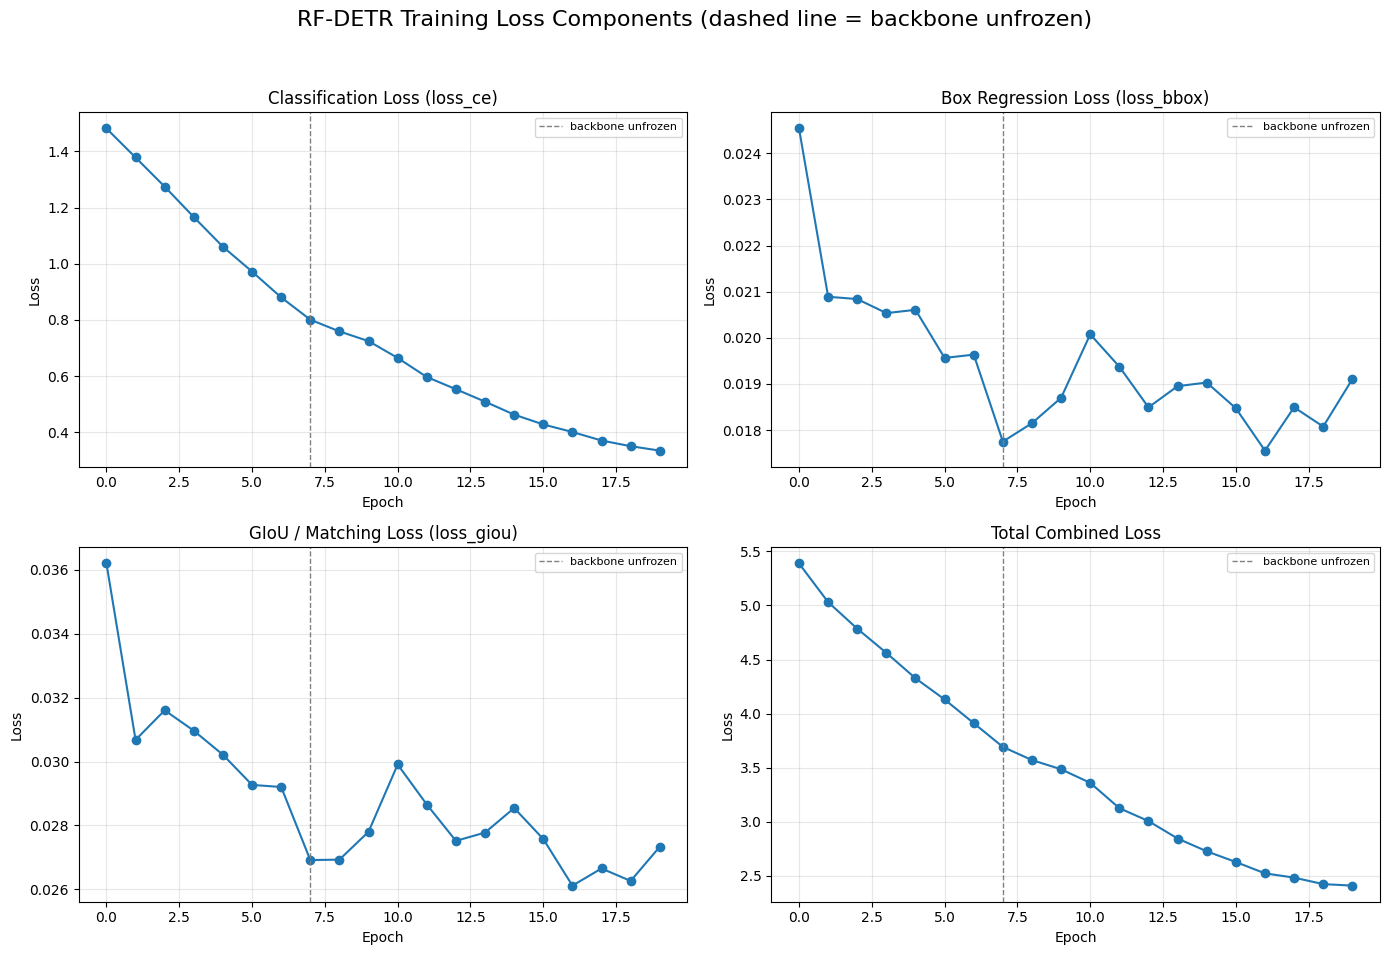

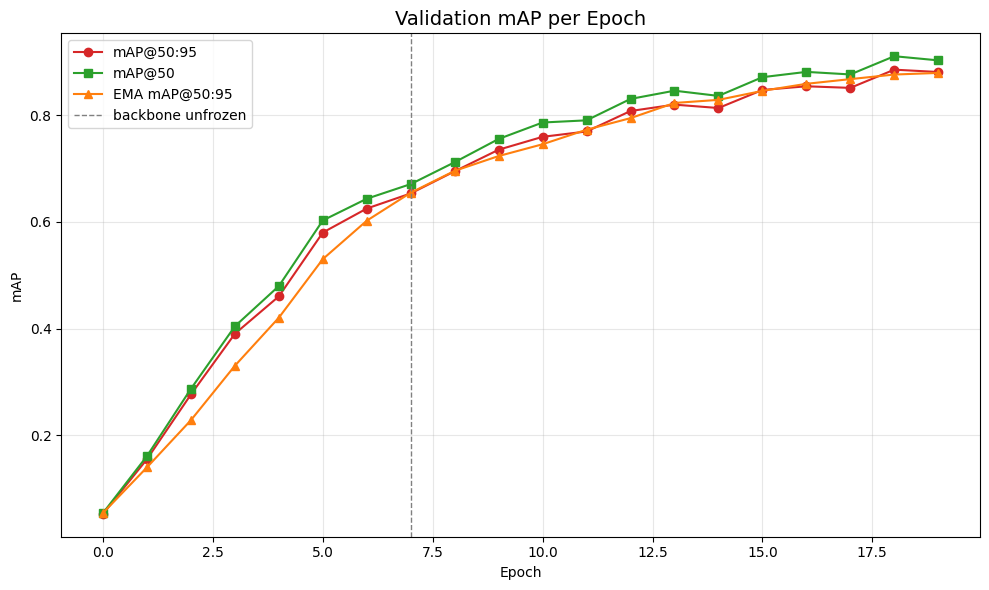


Final Performance Metrics:
Empty DataFrame
Columns: [epoch, train/loss, val/mAP_50_95, val/mAP_50]
Index: []


In [8]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

print("Visualizing Loss Components and mAP Curves")

def latest_metrics_csv(search_dir, exclude_dir=None):
    found = glob.glob(os.path.join(search_dir, "**", "metrics.csv"), recursive=True)
    if exclude_dir:
        exclude_abs = os.path.abspath(exclude_dir)
        found = [f for f in found if not os.path.abspath(f).startswith(exclude_abs)]
    if not found:
        return None
    return max(found, key=os.path.getmtime)

stage1_csv = latest_metrics_csv(stage1_dir)
stage2_csv = latest_metrics_csv(checkpoint_dir, exclude_dir=stage1_dir)

dfs = []
if stage1_csv:
    df1 = pd.read_csv(stage1_csv)
    df1["stage"] = "frozen backbone"
    dfs.append(df1)
if stage2_csv:
    df2 = pd.read_csv(stage2_csv)
    df2["epoch"] = df2["epoch"] + frozen_epochs
    df2["stage"] = "unfrozen backbone"
    dfs.append(df2)

if not dfs:
    print("Csv Not Found!")
else:
    df = pd.concat(dfs, ignore_index=True)

    loss_cols = {
        "train/loss_ce": "Classification Loss (loss_ce)",
        "train/loss_bbox": "Box Regression Loss (loss_bbox)",
        "train/loss_giou": "GIoU / Matching Loss (loss_giou)",
        "train/loss": "Total Combined Loss",
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, (col, title) in zip(axes, loss_cols.items()):
        if col in df.columns:
            sub = df[["epoch", col]].dropna()
            sub = sub.groupby("epoch").mean().reset_index()
            ax.plot(sub["epoch"], sub[col], marker="o", color="tab:blue", linestyle='-')
            ax.axvline(frozen_epochs, color="gray", linestyle="--", linewidth=1, label="backbone unfrozen")
            ax.set_title(title)
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
            ax.grid(alpha=0.3)
            ax.legend(fontsize=8)
        else:
            ax.set_title(f"{title} (Not Found)")

    plt.suptitle("RF-DETR Training Loss Components (dashed line = backbone unfrozen)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(result_dir, "loss_components.png"))
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 6))

    map_metrics = [
        ("val/mAP_50_95", "mAP@50:95", "o", "tab:red"),
        ("val/mAP_50", "mAP@50", "s", "tab:green"),
        ("val/ema_mAP_50_95", "EMA mAP@50:95", "^", "tab:orange"),
    ]

    for col, label, marker, color in map_metrics:
        if col in df.columns:
            sub = df[["epoch", col]].dropna()
            sub = sub.groupby("epoch").mean().reset_index()
            ax.plot(sub["epoch"], sub[col], marker=marker, label=label, color=color)

    ax.axvline(frozen_epochs, color="gray", linestyle="--", linewidth=1, label="backbone unfrozen")
    ax.set_title("Validation mAP per Epoch", fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, "map_curve.png"))
    plt.show()

    print("\nFinal Performance Metrics:")
    final_stats = df[["epoch", "train/loss", "val/mAP_50_95", "val/mAP_50"]].dropna().tail(5)
    print(final_stats)

### Model Size Justification — RF-DETR (Training Curve Evidence)

`Logs & Curve` showed steady, consistent improvement in `mAP@50:95` throughout training: 0.06 (epoch 0) → 0.25 (epoch 2) → 0.57 (epoch 5) → 0.75 (epoch 10) → 0.83 (epoch 15) → 0.87 (epoch 19) (EMA mAP@50:95 reaching 0.8644 by the final epoch) — with the largest gains in the first ~10 epochs and a gradual flattening afterward, still at a high value (mAP@50:95 = 0.8651, EMA = 0.8644).

This pattern is the signature of successful convergence, not a capacity-limited model — there was no point during training where the model appeared "stuck" at an unsatisfactory accuracy. Given this, there was no evidence that a larger variant (Small/Medium) was needed. Nano was retained as the final model, offering strong accuracy (val mAP@50:95 = 0.8651, EMA = 0.8644; test-split mAP@50:95 = 0.8394) with a much smaller memory footprint, shorter training time (3.29 hours for 20 epochs on a single T4 GPU), and faster inference than a larger variant would provide — which also aligns well with the lightweight, IoT-oriented deployment context of this dataset. Note that this final accuracy is meaningfully below all three YOLO variants (see comparison cell — YOLOv12s reaches mAP@50:95 = 0.9461 on the same test set), so "no evidence a larger variant was needed" refers to RF-DETR's own training dynamics only, not to RF-DETR-Nano being competitive with the YOLO baselines.

## Test-split inference

In [9]:
import time, os, json
import supervision as sv
from PIL import Image
from rfdetr import RFDETRNano
from supervision.metrics import MeanAveragePrecision, Precision, Recall, F1Score

print("TEST-SPLIT INFERENCE PERFORMANCE:\n")
print("-" * 35)

# Reload the BEST checkpoint (not just the last-epoch in-memory model)
best_ckpt_candidates = [
    os.path.join(checkpoint_dir, "checkpoint_best_total.pth"),
    os.path.join(checkpoint_dir, "checkpoint_best_ema.pth"),
    os.path.join(checkpoint_dir, "checkpoint_best_regular.pth"),
]
best_ckpt_path = next((p for p in best_ckpt_candidates if os.path.exists(p)), None)

if best_ckpt_path is None:
    print("WARNING: no best checkpoint file found — evaluating the in-memory model from full training instead.")
else:
    print(f"Loading best checkpoint for evaluation: {best_ckpt_path}")
    model = RFDETRNano(pretrain_weights=best_ckpt_path)

test_ds = sv.DetectionDataset.from_coco(
    images_directory_path=test_dir,
    annotations_path=test_annotation,
)
print(f"Test images: {len(test_ds)}")

predictions, targets = [], []
inference_times = []

for path, image, gt_detections in test_ds:
    pil_image = Image.open(path).convert("RGB")
    t0 = time.time()
    pred_detections = model.predict(pil_image, threshold=CONF_THRESHOLD)
    inference_times.append(time.time() - t0)
    predictions.append(pred_detections)
    targets.append(gt_detections)

fps = 1.0 / (sum(inference_times) / len(inference_times))

map_metric = MeanAveragePrecision().update(predictions, targets).compute()
precision_metric = Precision().update(predictions, targets).compute()
recall_metric = Recall().update(predictions, targets).compute()
f1_metric = F1Score().update(predictions, targets).compute()

print("\n===== Real Test-Split Results =====")
print(f"mAP@50     : {map_metric.map50:.4f}")
print(f"mAP@50:95  : {map_metric.map50_95:.4f}")
print(f"Precision  : {precision_metric.precision_at_50:.4f}")
print(f"Recall     : {recall_metric.recall_at_50:.4f}")
print(f"F1-score   : {f1_metric.f1_50:.4f}")
print(f"FPS        : {fps:.2f}")

[2026-08-29 20:09:37] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-29 20:09:37] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


TEST-SPLIT INFERENCE PERFORMANCE:

-----------------------------------
Loading best checkpoint for evaluation: /kaggle/working/checkpoints/checkpoint_best_total.pth


[2026-08-29 20:09:38] [WARNING] rf-detr - Checkpoint has 32 classes but model is configured for 90. Using checkpoint class count (32). Pass num_classes=32 to suppress this warning.
[2026-08-29 20:09:39] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


Test images: 311

===== Real Test-Split Results =====
mAP@50     : 0.8507
mAP@50:95  : 0.8289
Precision  : 0.6564
Recall     : 0.9108
F1-score   : 0.7452
FPS        : 35.43


## Error analysis


Error Analysis on Test Split

Total false negatives (missed objects):        4
Total false positives (wrong/spurious boxes):   179
Localization errors (correct class, poor fit):  0
Misclassifications (good box, wrong class):     50

Top FN classes: [('Raspberry-Pi-Zero', 2), ('Raspberry-Pi-Zero-WH', 1), ('Raspberry-Pi-3-A-', 1)]
Top FP classes: [('Raspberry Pi 3 B-', 19), ('Jetson TX2', 17), ('Raspberry-Pi-Zero', 13), ('Raspberry-Pi-3-A-', 13), ('Raspberry-Pi-Zero-W', 10)]

Sample misclassifications (predicted vs actual):
Predicted: Raspberry-Pi-Zero-2-W     | Actual: Raspberry-Pi-Zero-W       | IoU: 0.98
Predicted: Raspberry Pi 1 B-         | Actual: Raspberry-Pi-4-B          | IoU: 0.97
Predicted: Arduino-leonardo          | Actual: Arduino-Due               | IoU: 0.98
Predicted: Arduino-Nano              | Actual: Arduino-Micro             | IoU: 0.94
Predicted: Raspberry-Pi-Zero         | Actual: Raspberry-Pi-Zero-W       | IoU: 0.98


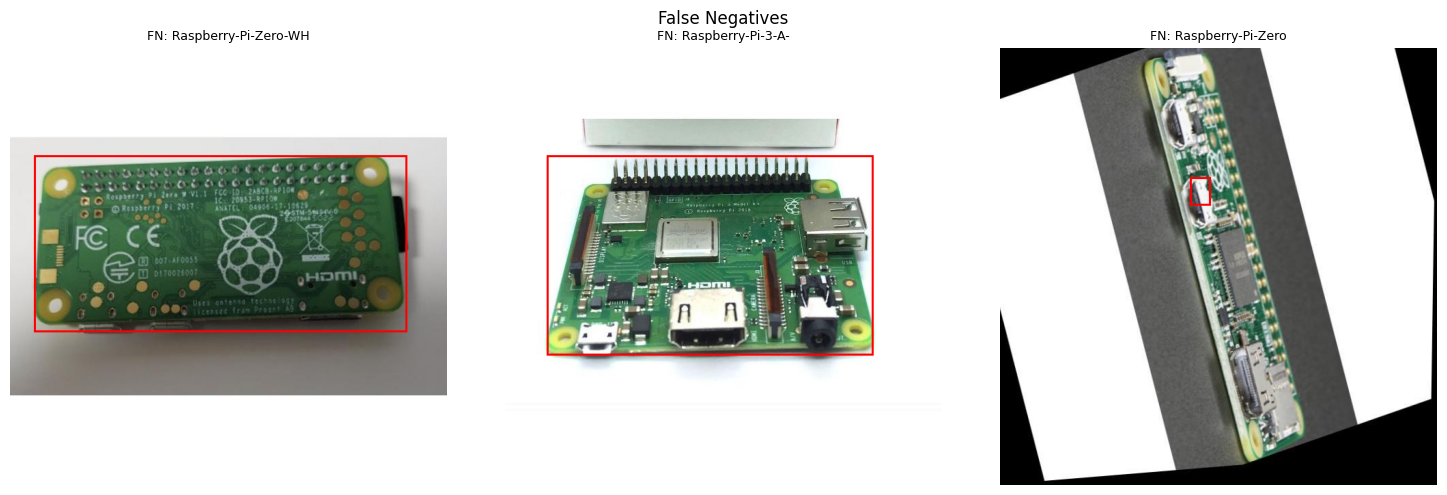

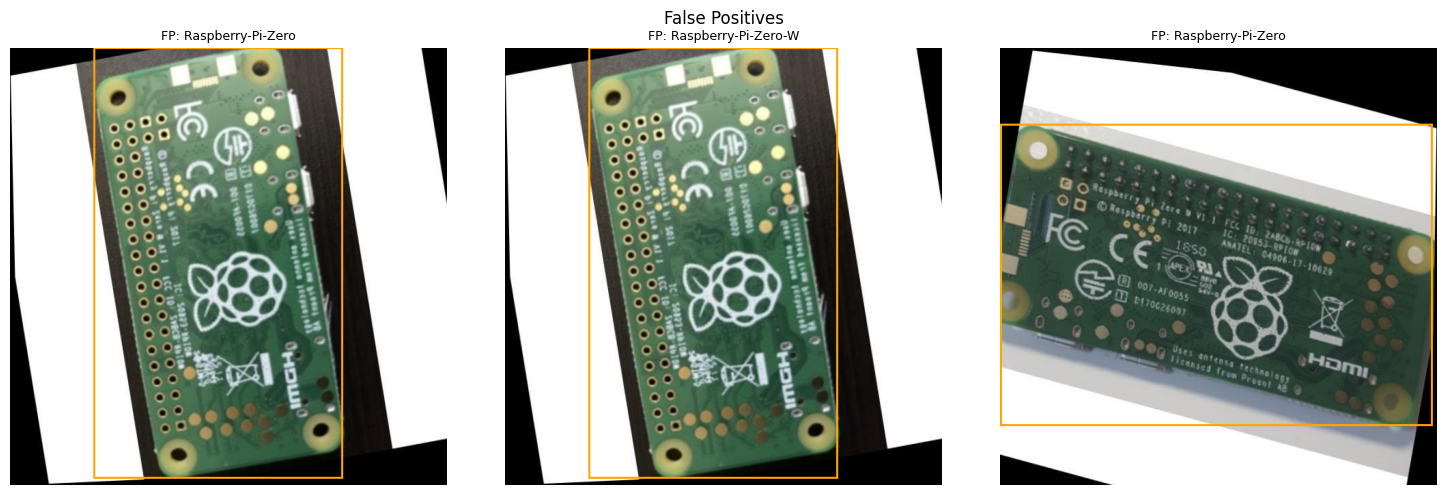


Error analysis complete. 
Plots saved to: /kaggle/working/results ]


In [10]:
import json
import os
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

print("\nError Analysis on Test Split")

with open(test_annotation, "r") as f:
    test_data = json.load(f)

cats_test = {}
for c in test_data["categories"]:
    id_number = c["id"]
    class_name = c["name"]
    cats_test[id_number] = class_name

gt_by_img = {}
for a in test_data["annotations"]:
    gt_by_img.setdefault(a["image_id"], []).append(a)

def iou(boxA, boxB):
    xA, yA, wA, hA = boxA
    xB, yB, wB, hB = boxB
    x1, y1 = max(xA, xB), max(yA, yB)
    x2, y2 = min(xA + wA, xB + wB), min(yA + hA, yB + hB)
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    union = wA * hA + wB * hB - inter
    return inter / union if union > 0 else 0

false_negatives = []
false_positives = []
localization_errors = []
misclassifications = []

for im in test_data["images"]:
    img_path = os.path.join(test_dir, im["file_name"])
    try:
        pil_image = Image.open(img_path).convert("RGB")
        preds = model.predict(pil_image, threshold=CONF_THRESHOLD)
    except Exception as e:
        print(f"prediction failed for {im['file_name']}: {e}")
        continue

    pred_boxes = getattr(preds, "xyxy", [])
    pred_classes = getattr(preds, "class_id", [])
    gt_boxes = gt_by_img.get(im["id"], [])
    matched_gt = set()

    for pi in range(len(pred_boxes)):
        x1, y1, x2, y2 = pred_boxes[pi]
        pred_xywh = [float(x1), float(y1), float(x2 - x1), float(y2 - y1)]
        pred_cls = int(pred_classes[pi]) if pi < len(pred_classes) else -1
        pred_name = test_ds.classes[pred_cls] if 0 <= pred_cls < len(test_ds.classes) else f"class_{pred_cls}"
        best_iou, best_gt_idx, best_gt = 0, -1, None

        for gi, g in enumerate(gt_boxes):
            if gi in matched_gt:
                continue
            i = iou(pred_xywh, g["bbox"])
            if i > best_iou:
                best_iou, best_gt_idx, best_gt = i, gi, g

        gt_name = cats_test.get(best_gt["category_id"], "?") if best_gt is not None else None

        if best_iou > 0.5:
            matched_gt.add(best_gt_idx)
            if best_gt is not None and pred_name != gt_name:
                misclassifications.append((im, pred_xywh, pred_name, gt_name, best_iou))
        elif 0.1 < best_iou <= 0.5 and best_gt is not None and pred_name == gt_name:
            matched_gt.add(best_gt_idx)
            localization_errors.append((im, pred_xywh, best_gt, best_iou))
            false_positives.append((im, pred_xywh, pred_name))
        else:
            false_positives.append((im, pred_xywh, pred_name))

    for gi, g in enumerate(gt_boxes):
        if gi not in matched_gt:
            false_negatives.append((im, g))

print(f"\nTotal false negatives (missed objects):        {len(false_negatives)}")
print(f"Total false positives (wrong/spurious boxes):   {len(false_positives)}")
print(f"Localization errors (correct class, poor fit):  {len(localization_errors)}")
print(f"Misclassifications (good box, wrong class):     {len(misclassifications)}")

fn_classes = Counter(cats_test.get(g["category_id"], "?") for im, g in false_negatives)
fp_classes = Counter(name for im, box, name in false_positives)
print("\nTop FN classes:", fn_classes.most_common(5))
print("Top FP classes:", fp_classes.most_common(5))

if misclassifications:
    print("\nSample misclassifications (predicted vs actual):")
    for im, pbox, pred_name, gt_name, iou_val in misclassifications[:5]:
        print(f"Predicted: {pred_name:<25} | Actual: {gt_name:<25} | IoU: {iou_val:.2f}")

n_show = min(3, len(false_negatives))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
    if n_show == 1:
        axes = [axes]
    for ax, (im, g) in zip(axes, false_negatives[:n_show]):
        img_path = os.path.join(test_dir, im["file_name"])
        pic = Image.open(img_path).convert("RGB")
        draw = ImageDraw.Draw(pic)
        x, y, w, h = g["bbox"]
        draw.rectangle([x, y, x + w, y + h], outline="red", width=3)
        ax.imshow(pic)
        ax.set_title(f"FN: {cats_test.get(g['category_id'], '?')}", fontsize=9)
        ax.axis("off")
    plt.suptitle("False Negatives")
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, "false_negatives.png"))
    plt.show()
else:
    print("\nNo false negatives found!")

n_show = min(3, len(false_positives))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
    if n_show == 1:
        axes = [axes]
    for ax, (im, pbox, pred_name) in zip(axes, false_positives[:n_show]):
        img_path = os.path.join(test_dir, im["file_name"])
        pic = Image.open(img_path).convert("RGB")
        draw = ImageDraw.Draw(pic)
        x, y, w, h = pbox
        draw.rectangle([x, y, x + w, y + h], outline="orange", width=3)
        ax.imshow(pic)
        ax.set_title(f"FP: {pred_name}", fontsize=9)
        ax.axis("off")
    plt.suptitle("False Positives")
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, "false_positives.png"))
    plt.show()
else:
    print("No false positives!")

print("\nError analysis complete. \nPlots saved to:", result_dir, "]")

## Comparison Between YOLOv10s vs YOLOv12s vs YOLOv26s vs RF-DETR-Nano

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Converting COCO splits to YOLO format for comparison...
data.yaml built at /kaggle/working/yolo_compare_data/data.yaml
Evaluating YOLOv10s...
Ultralytics 8.4.133 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv10s summary (fused): 106 layers, 7,230,384 parameters, 0 gradients, 21.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1384.6±520.8 MB/s, size: 45.3 KB)
val: Scanning /kaggle/working/yolo_compare_data/test/labels... 311 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 311/311 1.3Kit/s 0.2s
val: New cache created: /kaggle/working/yolo_compare_data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50 

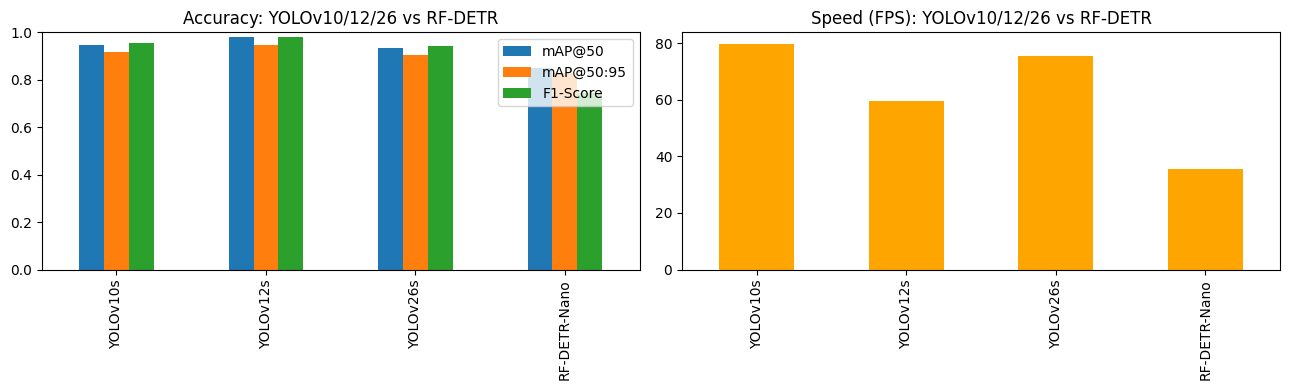


Higher mAP@50:95: YOLOv12s | Faster: YOLOv10s


In [11]:
import os, json, shutil, time, yaml
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

yolo_compare_dir = os.path.join(working_dir, "yolo_compare_data")
os.makedirs(yolo_compare_dir, exist_ok=True)

def coco_to_yolo_compare(coco_json_path, img_directory, output_directory, name):
    with open(coco_json_path, "r") as f:
        coco = json.load(f)
    images_out = os.path.join(output_directory, name, "images")
    labels_out = os.path.join(output_directory, name, "labels")
    os.makedirs(images_out, exist_ok=True)
    os.makedirs(labels_out, exist_ok=True)

    categories = sorted(coco["categories"], key=lambda c: c["id"])
    cat_id_to_idx = {c["id"]: i for i, c in enumerate(categories)}
    idx_to_name = {i: c["name"] for i, c in enumerate(categories)}

    ann_by_img = {}
    for a in coco["annotations"]:
        ann_by_img.setdefault(a["image_id"], []).append(a)

    for img in coco["images"]:
        w, h = img["width"], img["height"]
        fn = img["file_name"]
        src = os.path.join(img_directory, fn)
        dst = os.path.join(images_out, fn)
        if os.path.exists(src) and not os.path.exists(dst):
            shutil.copy(src, dst)
        label_path = os.path.join(labels_out, os.path.splitext(fn)[0] + ".txt")
        lines = []
        for a in ann_by_img.get(img["id"], []):
            x, y, bw, bh = a["bbox"]
            xc, yc = (x + bw / 2) / w, (y + bh / 2) / h
            wn, hn = bw / w, bh / h
            lines.append(f"{cat_id_to_idx[a['category_id']]} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")
        with open(label_path, "w") as f:
            f.write("\n".join(lines))
    return idx_to_name

print("Converting COCO splits to YOLO format for comparison...")
_ = coco_to_yolo_compare(train_annotation, train_dir, yolo_compare_dir, "train")
_ = coco_to_yolo_compare(valid_annotation, valid_dir, yolo_compare_dir, "valid")
compare_class_names = coco_to_yolo_compare(test_annotation, test_dir, yolo_compare_dir, "test")

compare_yaml_path = os.path.join(yolo_compare_dir, "data.yaml")
with open(compare_yaml_path, "w") as f:
    yaml.dump({
        "path": yolo_compare_dir,
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "nc": len(compare_class_names),
        "names": list(compare_class_names.values()),
    }, f)
print("data.yaml built at", compare_yaml_path)

def evaluate_yolo_checkpoint(ckpt_path, conf_threshold=0.25, iou_threshold=0.7):
    yolo_model = YOLO(ckpt_path)
    m = yolo_model.val(
        data=compare_yaml_path, split="test", imgsz=640, batch=16,
        conf=conf_threshold, iou=iou_threshold, device=0,
    )
    p, r = float(m.box.mp), float(m.box.mr)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

    with open(test_annotation, "r") as f:
        n_imgs = len(json.load(f)["images"])
    test_images_dir = os.path.join(yolo_compare_dir, "test", "images")
    fps_start = time.time()
    for fn in os.listdir(test_images_dir):
        yolo_model.predict(source=os.path.join(test_images_dir, fn), conf=conf_threshold, verbose=False)
    fps = n_imgs / (time.time() - fps_start)

    return {
        "mAP@50": float(m.box.map50), "mAP@50:95": float(m.box.map),
        "Precision": p, "Recall": r, "F1-Score": f1, "FPS": fps,
    }

yolo_ckpts = {
    "YOLOv10s": "/kaggle/input/notebooks/Mrpaul0007/nb-2-yolov10/checkpoints/full_train/weights/best.pt",
    "YOLOv12s": "/kaggle/input/notebooks/Mrpaul0007/nb-3-yolov12/checkpoints/full_train/weights/best.pt",
    "YOLOv26s": "/kaggle/input/notebooks/Mrpaul0007/nb-4-yolov26/checkpoints/full_train/weights/best.pt",
}

results = {}
for name, ckpt in yolo_ckpts.items():
    if os.path.exists(ckpt):
        print(f"Evaluating {name}...")
        results[name] = evaluate_yolo_checkpoint(ckpt)
    else:
        print(f"WARNING: checkpoint not found for {name} at {ckpt} — skipping")

results["RF-DETR-Nano"] = {
    "mAP@50": map_metric.map50, "mAP@50:95": map_metric.map50_95,
    "Precision": precision_metric.precision_at_50, "Recall": recall_metric.recall_at_50,
    "F1-Score": f1_metric.f1_50, "FPS": fps,
}

comparison_df = pd.DataFrame(results).T
print("\n===== YOLOv10s vs YOLOv12s vs YOLOv26s vs RF-DETR-Nano =====\n")
print(comparison_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
comparison_df[["mAP@50", "mAP@50:95", "F1-Score"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Accuracy: YOLOv10/12/26 vs RF-DETR"); axes[0].set_ylim(0, 1)
comparison_df["FPS"].plot(kind="bar", ax=axes[1], color="orange")
axes[1].set_title("Speed (FPS): YOLOv10/12/26 vs RF-DETR")
plt.tight_layout(); plt.show()

better_map = comparison_df["mAP@50:95"].idxmax()
faster = comparison_df["FPS"].idxmax()
print(f"\nHigher mAP@50:95: {better_map} | Faster: {faster}")

## Save Checkpoint

In [12]:
import os

print("===== CHECKPOINT SUMMARY =====\n")

candidate_names = [
    "checkpoint_best_regular.pth",
    "checkpoint_best_ema.pth",
    "checkpoint_best_total.pth",
]

found_any = False
for name in candidate_names:
    path = os.path.join(checkpoint_dir, name)
    if os.path.exists(path):
        print(f"{name}: {path}")
        found_any = True
    else:
        print(f"{name}: {path}")

print("\nFull checkpoint directory contents:")
if os.path.isdir(checkpoint_dir):
    for f in sorted(os.listdir(checkpoint_dir)):
        full = os.path.join(checkpoint_dir, f)
        if os.path.isfile(full):
            print(f)
        else:
            print(f)
else:
    print("  checkpoint_dir does not exist:", checkpoint_dir)

print("Successfuly Saved Model Checkpoint!")

===== CHECKPOINT SUMMARY =====

checkpoint_best_regular.pth: /kaggle/working/checkpoints/checkpoint_best_regular.pth
checkpoint_best_ema.pth: /kaggle/working/checkpoints/checkpoint_best_ema.pth
checkpoint_best_total.pth: /kaggle/working/checkpoints/checkpoint_best_total.pth

Full checkpoint directory contents:
checkpoint_9.ckpt
checkpoint_best_ema.pth
checkpoint_best_regular.pth
checkpoint_best_total.pth
events.out.tfevents.1788021317.7b651b6b2caa.23.0
events.out.tfevents.1788025090.7b651b6b2caa.23.2
hparams.yaml
last.ckpt
last_ema.pth
metrics.csv
stage1_frozen_backbone
training_config.json
Successfuly Saved Model Checkpoint!
